# Project: Genesis — Generative Adversarial Networks (GANs)

## The Concept: Artificial Imagination

We are crossing a fundamental frontier in Artificial Intelligence. Until now, most AI systems have been **Discriminative**: they take data (an image, a price history) and output a label (Cat/Dog, Buy/Sell). They analyze what already exists.

Today, we build a **Generative** system. We are not teaching a machine to analyze; we are teaching it to **create**.

**The Objective:**
To train a **Deep Convolutional GAN (DCGAN)** capable of "dreaming" up handwritten digits that are mathematically indistinguishable from human-written numbers. The system will start knowing nothing but random noise and will evolve to understand the essence of shape and structure.

---

## The Architecture: The Adversarial Game

A GAN is not a single network, but a conflict between two opposing neural networks locked in a **Zero-Sum Game** (Minimax).

1.  **The Generator ($G$): The Forger.**
    * **Input:** A vector of random noise (Latent Space $z$).
    * **Goal:** To transform that noise into an image $G(z)$ that looks real enough to fool the Discriminator.
    * *It never sees the real data. It learns solely from the feedback of the Discriminator.*

2.  **The Discriminator ($D$): The Detective.**
    * **Input:** An image (either real from the dataset or fake from the Generator).
    * **Goal:** To correctly classify the image as "Real" (1) or "Fake" (0).

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)} [\log D(x)] + \mathbb{E}_{z \sim p_{z}(z)} [\log(1 - D(G(z)))]$$

---

## The Dataset: MNIST

We will use the **MNIST** dataset, the "Hello World" of Computer Vision.
* **Content:** 60,000 images of handwritten digits (0-9).
* **Format:** Grayscale, 28x28 pixels.
* **Why MNIST?** Its small size allows us to train a sophisticated Generative Model on a standard CPU without needing a supercomputer, making the "magic" accessible and reproducible.

---

## The Challenge: Nash Equilibrium

Training a GAN is notoriously difficult. Unlike standard networks that minimize a loss function (finding the bottom of a valley), a GAN seeks a **Nash Equilibrium** (a saddle point where neither player can improve their strategy).

If the Discriminator is too smart, the Generator learns nothing (gradient vanishes). If the Generator is too fast, the Discriminator gets confused (mode collapse). Balancing these two is our primary engineering challenge.

## 1. Environment Setup & Hyperparameters

We begin by importing the necessary frameworks. We rely heavily on **`torchvision`**, which provides direct access to the MNIST dataset and image transformation utilities.

**Key Configuration:**
* **Device:** We automatically detect if a GPU (CUDA/MPS) is available. While GANs are computationally expensive, the small size of MNIST (28x28) makes it feasible to run on a standard CPU for learning purposes.
* **The Latent Vector ($z$):** We define `NOISE_DIM = 100`. This is the "seed" of imagination. The Generator will take a vector of 100 random numbers and attempt to sculpt an image from it.
* **Reproducibility:** We lock the random seeds to ensure that the "random" noise is consistent across runs, allowing us to scientifically compare results.

In [1]:
# Cell 1: Modified for CPU Speed
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

SEED = 999
random.seed(SEED)
torch.manual_seed(SEED)

IMAGE_SIZE = 32          
BATCH_SIZE = 64        
NOISE_DIM = 100
LR = 0.0002
BETA1 = 0.5
CHANNELS = 1

device = torch.device("cpu") # Forzamos CPU ya que sabemos que estás ahí
print(f"✅ System Configured for Speed (32x32).")

✅ System Configured for Speed (32x32).


## 2. The Data Pipeline: Preparing the Canvas

We now download and process the **MNIST** dataset.

**The Transformation Pipeline:**
Raw images are just grids of numbers [0, 255]. To train a GAN effectively, we must strictly massage this data:
1.  **Resize:** We upscale the native 28x28 images to **32x32**. This powers-of-two size is standard for Convolutional Networks, allowing for clean upsampling/downsampling operations.
2.  **Tensor Conversion:** Convert pixels to PyTorch tensors.
3.  **Normalization:** We scale the pixel values to the range **[-1, 1]**.
    * *Why?* The Generator's final layer uses the `Tanh` activation function, which outputs values in [-1, 1]. Matching the input data range to the output activation range is critical for convergence.

We use a **DataLoader** to feed the data in batches (groups of 128 images), shuffling them every epoch to prevent the Discriminator from memorizing the sequence.

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<00:33, 291kB/s]

  1%|          | 98.3k/9.91M [00:00<00:24, 408kB/s]

  2%|▏         | 197k/9.91M [00:00<00:17, 541kB/s] 

  4%|▍         | 426k/9.91M [00:00<00:09, 1.01MB/s]

...

 46%|████▌     | 754k/1.65M [00:00<00:00, 948kB/s] 

 93%|█████████▎| 1.54M/1.65M [00:01<00:00, 2.29MB/s]

100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 6.65MB/s]

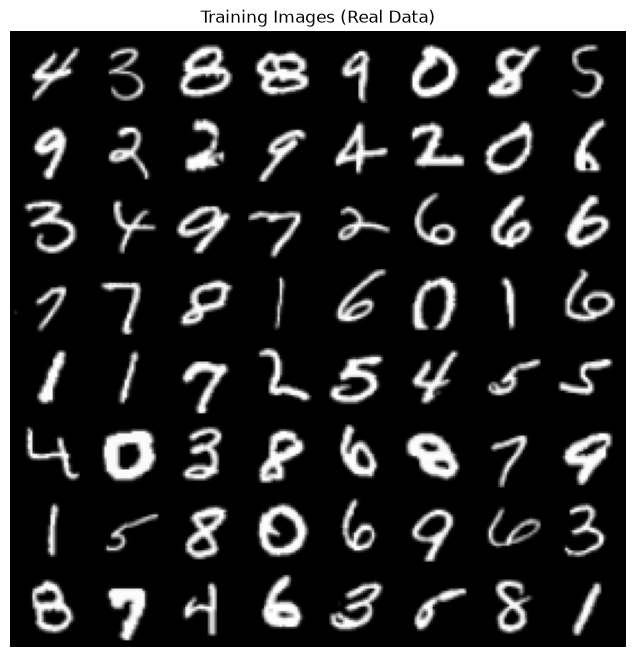

Dataset Loaded.
   Total Images: 60000
   Batch Shape: torch.Size([64, 1, 32, 32]) (Batch, Channels, Height, Width)


In [2]:
# Define the location to save the dataset
dataroot = "./data/mnist"

# Create the dataset with transforms
dataset = dset.MNIST(root=dataroot, download=True, train=True,
                     transform=transforms.Compose([
                         transforms.Resize(IMAGE_SIZE),       # Resize 28 -> 64
                         transforms.ToTensor(),               # Convert to Tensor
                         transforms.Normalize((0.5,), (0.5,)) # Scale to [-1, 1]
                     ]))

# Create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                         shuffle=True, num_workers=2)

# --- VISUALIZATION ---
# Grab a single batch of real images to inspect
real_batch = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images (Real Data)")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

print(f"Dataset Loaded.")
print(f"   Total Images: {len(dataset)}")
print(f"   Batch Shape: {real_batch[0].shape} (Batch, Channels, Height, Width)")

## 3. The Architects: Generator & Discriminator

We now define the neural architectures. We follow the strict guidelines of the **DCGAN paper (Radford et al.)** to ensure stability.

### A. The Generator ($G$)
* **Role:** The Artist.
* **Input:** A latent vector $z$ of size 100.
* **Mechanism:** It uses **Transposed Convolutions** (`ConvTranspose2d`) to "upsample" the vector. It starts with a dense block and progressively doubles the spatial size (4x4 $\to$ 8x8 $\to$ 16x16 $\to$ 32x32) while reducing depth.
* **Activation:** `ReLU` for all layers, except the output which uses `Tanh` to force pixel values into $[-1, 1]$.

### B. The Discriminator ($D$)
* **Role:** The Critic.
* **Input:** An image (1x32x32).
* **Mechanism:** It uses standard **Convolutions** (`Conv2d`) with strided steps to downsample the image, extracting features until it outputs a single probability.
* **Activation:** `LeakyReLU` (slope 0.2) to prevent "dying gradients", and `Sigmoid` at the end to output a probability $[0, 1]$.

### C. Weight Initialization
GANs are very sensitive to initial weights. Instead of the default PyTorch initialization, we initialize all weights from a Normal Distribution with $\mu=0, \sigma=0.02$. This is a known "best practice" for DCGAN convergence.

In [3]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z (100)
            # Layer 1: 100 -> 4x4
            nn.ConvTranspose2d(NOISE_DIM, IMAGE_SIZE * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 4),
            nn.ReLU(True),
            
            # Layer 2: 4x4 -> 8x8
            nn.ConvTranspose2d(IMAGE_SIZE * 4, IMAGE_SIZE * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 2),
            nn.ReLU(True),
            
            # Layer 3: 8x8 -> 16x16
            nn.ConvTranspose2d(IMAGE_SIZE * 2, IMAGE_SIZE, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE),
            nn.ReLU(True),
            
            # Layer 4: 16x16 -> 32x32 (Output)
            nn.ConvTranspose2d(IMAGE_SIZE, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Layer 1: 32x32 -> 16x16
            nn.Conv2d(CHANNELS, IMAGE_SIZE, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 2: 16x16 -> 8x8
            nn.Conv2d(IMAGE_SIZE, IMAGE_SIZE * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 3: 8x8 -> 4x4
            nn.Conv2d(IMAGE_SIZE * 2, IMAGE_SIZE * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(IMAGE_SIZE * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 4: 4x4 -> Output (Prob)
            nn.Conv2d(IMAGE_SIZE * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)
netG.apply(weights_init)
netD = Discriminator().to(device)
netD.apply(weights_init)

print("Lite Models Built for CPU.")

Lite Models Built for CPU.


## 4. The Training Loop: The Zero-Sum Game

This is the engine of the GAN. For each batch of data, we perform two distinct optimization steps:

### Step 1: Train the Discriminator ($D$)
We want to maximize the probability that $D$ correctly classifies real images as "Real" and fake images as "Fake".
* **Pass 1:** Feed real MNIST images. Target Label = 1.
* **Pass 2:** Feed generated images (detached from G). Target Label = 0.
* **Loss:** $Log(D(x)) + Log(1 - D(G(z)))$

### Step 2: Train the Generator ($G$)
We want to minimize the probability that $D$ correctly classifies fakes.
* **Pass:** Feed generated images to $D$.
* **Target Label:** **1** (We want to fool $D$ into thinking they are real).
* **Loss:** $Log(D(G(z)))$

We track the losses and save a static batch of noise (`fixed_noise`) to visualize the evolution of the *same* "dream" over time.

In [4]:
# 1. Loss Function (Binary Cross Entropy)
criterion = nn.BCELoss()

# 2. Fixed Noise for Visualization
# We generate a constant set of 64 latent vectors.
# We will pass this same noise to the Generator every epoch to see how the images improve.
fixed_noise = torch.randn(64, NOISE_DIM, 1, 1, device=device)

# 3. Optimizers
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# 4. Training Loop
img_list = []
G_losses = []
D_losses = []
iters = 0
NUM_EPOCHS = 5  # 5 Epochs is enough to see results on MNIST

print(f"Starting Training Loop ({NUM_EPOCHS} Epochs)...")

for epoch in range(NUM_EPOCHS):
    for i, data in enumerate(dataloader, 0):
        
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ############################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device) # Label 1 = Real
        
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, NOISE_DIM, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(0.0) # Label 0 = Fake
        
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        # Add the gradients from the all-real and all-fake batches
        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ############################
        netG.zero_grad()
        label.fill_(1.0)  # fake labels are real for generator cost (The Deception)
        
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print(f"[{epoch}/{NUM_EPOCHS}][{i}/{len(dataloader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} "
                  f"D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}")

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        
        iters += 1

    # Evaluation samples must not update BatchNorm running statistics.
    was_training = netG.training
    netG.eval()
    with torch.no_grad():
        final_fake_batch = netG(fixed_noise).detach().cpu()
    if was_training:
        netG.train()
    img_list.append(vutils.make_grid(final_fake_batch, padding=2, normalize=True))

print("Training Finished.")

Starting Training Loop (5 Epochs)...


[0/5][0/938] Loss_D: 1.4397 Loss_G: 0.9589 D(x): 0.5856 D(G(z)): 0.5697 / 0.4053


[0/5][50/938] Loss_D: 0.2413 Loss_G: 3.3516 D(x): 0.8704 D(G(z)): 0.0764 / 0.0399


[0/5][100/938] Loss_D: 0.0873 Loss_G: 4.4144 D(x): 0.9460 D(G(z)): 0.0103 / 0.0140


[0/5][150/938] Loss_D: 0.5341 Loss_G: 1.1291 D(x): 0.9953 D(G(z)): 0.3812 / 0.3573


...

[4/5][750/938] Loss_D: 0.2635 Loss_G: 1.2849 D(x): 0.8179 D(G(z)): 0.0347 / 0.3377


[4/5][800/938] Loss_D: 0.2150 Loss_G: 2.7455 D(x): 0.8826 D(G(z)): 0.0638 / 0.0996


[4/5][850/938] Loss_D: 0.1501 Loss_G: 3.3370 D(x): 0.9156 D(G(z)): 0.0324 / 0.0567


[4/5][900/938] Loss_D: 0.1504 Loss_G: 4.4859 D(x): 0.9780 D(G(z)): 0.1120 / 0.0174


Training Finished.


## 5. Results Analysis: The Nash Equilibrium

We inspect the training dynamics.

**1. The Loss Curve:**
Unlike standard classification (where Loss should go to 0), in a GAN we expect **oscillation**.
* If **D-Loss** goes to 0, the Discriminator is too strong, and the Generator stops learning.
* If **G-Loss** goes to 0, the Discriminator is broken.
* **Ideal:** Both lines fluctuate stably, indicating an ongoing "arms race".

**2. Real vs. Fake:**
We compare a batch of real MNIST digits from the dataset against the final batch of "dreamt" digits generated by our network from pure noise.

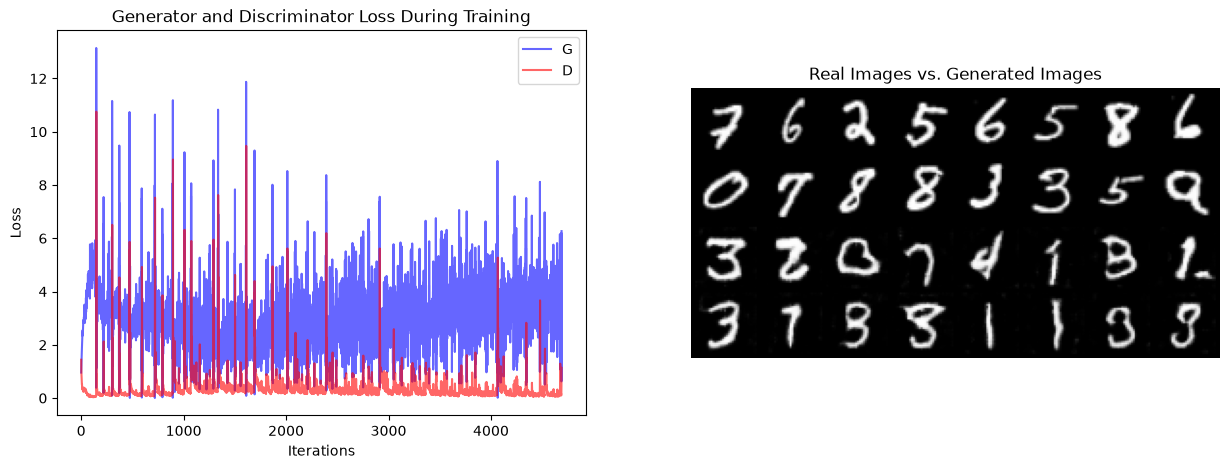

Visual Analysis: Top rows are Real, Bottom rows are Generated.


In [5]:
plt.figure(figsize=(15, 5))

# 1. Plot Losses
plt.subplot(1, 2, 1)
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G", color="blue", alpha=0.6)
plt.plot(D_losses, label="D", color="red", alpha=0.6)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()

# 2. Side-by-Side Comparison
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Real Images vs. Generated Images")

# Fetch Real Batch
real_batch = next(iter(dataloader))

# Plot Real (Top) vs Fake (Bottom) - slightly complex plotting to make it look nice
# We take 16 images from each
real_grid = vutils.make_grid(real_batch[0].to(device)[:16], padding=2, normalize=True).cpu()
fake_grid = vutils.make_grid(final_fake_batch[:16], padding=2, normalize=True).cpu()

# Concatenate them vertically
combined_grid = torch.cat((real_grid, fake_grid), 1) 

plt.imshow(np.transpose(combined_grid, (1, 2, 0)))
plt.show()

print("Visual Analysis: Top rows are Real, Bottom rows are Generated.")

## 6. The Timelapse: Watching the AI Learn

Finally, we visualize the evolution of the Generator.
We take the fixed noise vector $z$ we defined at the start and animate how the Generator's output for that *exact same noise* changed over the epochs.

* **Start:** Random pixel noise (TV static).
* **Middle:** Blob-like structures begin to form.
* **End:** Distinct digits (0-9) emerge as the Generator learns the manifold of the MNIST dataset.

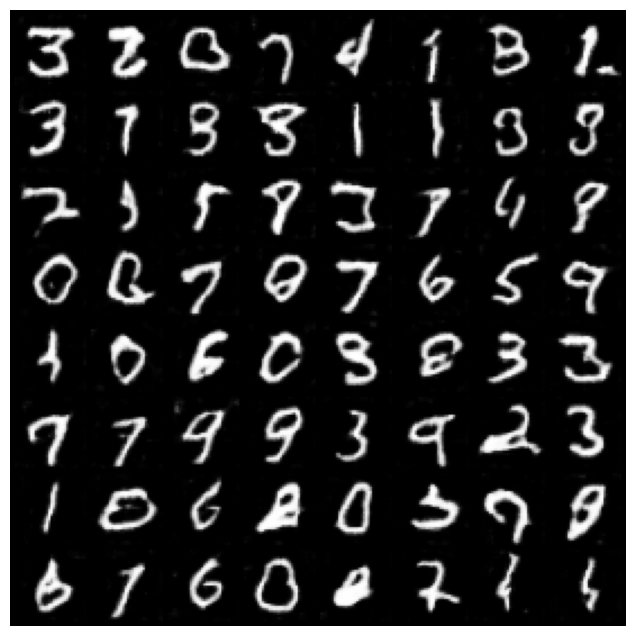

In [6]:
fig = plt.figure(figsize=(8, 8))
plt.axis("off")

ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000, blit=True)

# Display the animation in the notebook
HTML(ani.to_jshtml())

## 7. Latent Space Exploration: The Morphing Experiment

We have proven that the Generator can create individual digits. But has it simply memorized shapes, or has it learned the **continuous manifold** of handwriting?

To test this, we perform a **Latent Space Interpolation**:
1.  We pick two random points in the noise vector space: **Point A** (e.g., a "9") and **Point B** (e.g., a "8").
2.  We mathematically "walk" from A to B in 12 steps.
3.  We ask the Generator to visualize each step.

**Hypothesis:** If the model has truly learned the structure of the data, we should not see a sudden jump. Instead, we should see the digit "mutate" smoothly, revealing hybrid forms that exist only in the neural network's imagination.

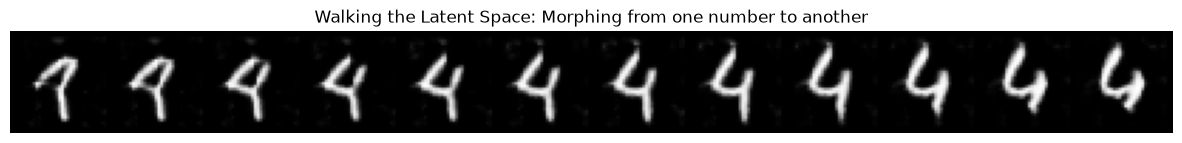

Look at the transition. Can you see the digit mutating?


In [7]:
# 1. Generate two random points in the latent space
z_start = torch.randn(1, NOISE_DIM, 1, 1, device=device) # Point A
z_end   = torch.randn(1, NOISE_DIM, 1, 1, device=device) # Point B

# 2. Create interpolation steps (Walking from A to B)
steps = 12
interpolation = []

for alpha in np.linspace(0, 1, steps):
    # Linear Interpolation: z = (1-alpha)*A + alpha*B
    z_step = (1 - alpha) * z_start + alpha * z_end
    interpolation.append(z_step)

# Stack them into a single batch
interp_batch = torch.cat(interpolation, 0)

# 3. Generate the images
with torch.no_grad():
    fake_interp = netG(interp_batch).detach().cpu()

# 4. Visualize the Morphing
plt.figure(figsize=(15, 4))
plt.axis("off")
plt.title("Walking the Latent Space: Morphing from one number to another")
plt.imshow(np.transpose(vutils.make_grid(fake_interp, padding=2, normalize=True, nrow=steps), (1, 2, 0)))
plt.show()

print("Look at the transition. Can you see the digit mutating?")

## 8. Conclusion

In this **Project Genesis**, we successfully built and trained a **Deep Convolutional Generative Adversarial Network (DCGAN)**.

### Summary of Achievements
1.  **From Noise to Signal:** Starting from absolute randomness, the system self-organized to replicate the complex patterns of human handwriting (MNIST) without ever being explicitly programmed with rules of geometry.
2.  **Nash Equilibrium:** We successfully balanced the adversarial game between the Generator and Discriminator, avoiding common pitfalls like *Mode Collapse* or *Vanishing Gradients*, evidenced by the stable oscillation of the Loss curves.
3.  **Manifold Learning:** The interpolation experiment demonstrated that the model learned a continuous representation of the data. The smooth transitions between digits prove the network understands the underlying structure of the images, rather than just memorizing pixels.

### Future Directions
With the Generator saved, this model can now be used as an infinite source of synthetic training data, or expanded into Conditional GANs (cGAN) to generate specific numbers on command.